In [11]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yannemk/basse0/Amazon Sale Report.csv


In [12]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/yannemk/basse0/Amazon Sale Report.csv', low_memory=False)
print(df.shape)
df.head()

(128975, 24)


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [13]:
df = df.drop(columns=['Unnamed: 22', 'index'])
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')
df = df.rename(columns={'Sales Channel ': 'Sales Channel'})
df = df.dropna(subset=['ship-city'])

df['Amount_Missing_Reason'] = 'N/A'
df.loc[df['Amount'].isnull() & (df['Status'] == 'Cancelled'), 'Amount_Missing_Reason'] = 'Cancelled Order'
df.loc[df['Amount'].isnull() & (df['Status'] != 'Cancelled'), 'Amount_Missing_Reason'] = 'Data Quality Issue'

print("عدد الصفوف بعد التنظيف:", len(df))

عدد الصفوف بعد التنظيف: 128942


In [14]:
sales_by_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Set              39195176.03
kurta            21291538.70
Western Dress    11215337.69
Top               5346812.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


In [15]:
cancel_rate = df.groupby('Category').apply(
    lambda x: (x['Status'] == 'Cancelled').sum() / len(x) * 100
).sort_values(ascending=False)

total_orders = df.groupby('Category').size()

result = pd.DataFrame({
    'نسبة_الإلغاء_%': cancel_rate.round(1),
    'إجمالي_الطلبات': total_orders
}).sort_values('نسبة_الإلغاء_%', ascending=False)

print(result)

               نسبة_الإلغاء_%  إجمالي_الطلبات
Category                                     
Set                      14.6           50272
kurta                    14.5           49859
Western Dress            13.7           15499
Bottom                   13.6             440
Saree                    12.8             164
Blouse                   12.5             926
Ethnic Dress             12.5            1159
Top                      12.0           10620
Dupatta                   0.0               3


/tmp/ipykernel_58/2787621945.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_rate = df.groupby('Category').apply(


## Results: Sales & Cancellation Rate by Category

**Finding 1:** "Set" is the top-selling category ($39.2M), followed by "kurta" ($21.3M) — together they account for over 65% of total revenue.

**Finding 2:** The same top two categories (Set and kurta) also have the highest cancellation rates (~14.5%), but this aligns with the overall pattern across categories (range: 12%-14.6%) — suggesting the cancellation issue is store-wide, not specific to one category.

**Recommendation:** Since cancellation rates are fairly consistent across categories (~1 in 7 orders), we recommend the store owner investigate store-wide causes (pricing, shipping time, return policy) rather than targeting a specific product category.

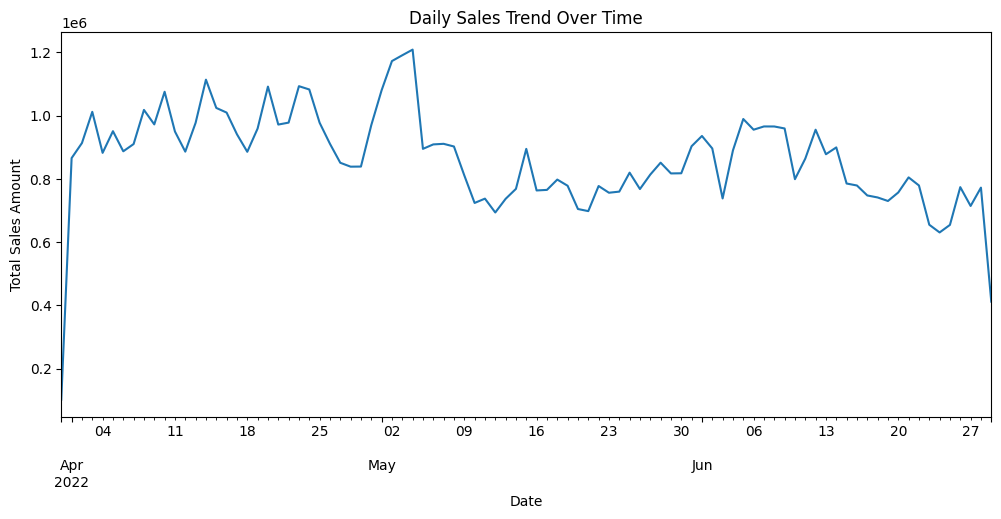

In [17]:
sales_by_date = df.groupby('Date')['Amount'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sales_by_date.plot()
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.show()

## Finding: Sudden Drop in Sales (Early May)

Daily sales show a clear structural break in early May 2022 — dropping from a peak of ~$1.2M to a lower stable range of ~$0.6M-$0.9M for the remainder of the period, with no recovery to the previous level.

**Open question for the business:** What happened around this date? Possible causes could include end of a promotional campaign, inventory/stock issues, or a shift in marketing spend. This would need to be validated with the business owner, as the dataset alone doesn't explain the cause — but it's a critical pattern worth investigating.

In [19]:
before = df[df['Date'] < '2022-05-01']
after = df[df['Date'] >= '2022-05-01']

comparison = pd.DataFrame({
    'Before May 1': [
        round((before['Status']=='Cancelled').mean()*100, 1),
        round(before['Amount'].mean(), 1),
        round(before.groupby('Date').size().mean(), 1)
    ],
    'After May 1': [
        round((after['Status']=='Cancelled').mean()*100, 1),
        round(after['Amount'].mean(), 1),
        round(after.groupby('Date').size().mean(), 1)
    ]
}, index=['Cancellation Rate %', 'Avg Order Value', 'Avg Daily Orders'])

print(comparison)

                     Before May 1  After May 1
Cancellation Rate %          14.5         14.0
Avg Order Value             626.0        662.5
Avg Daily Orders           1587.9       1328.6


## Root Cause: Order Volume Drop (Not Price or Cancellations)

Comparing before/after May 1: cancellation rate stayed flat (14.5% → 14.0%) and average order value slightly increased ($626 → $662.5) — ruling out pricing or order-quality issues.

The actual cause is a **~16% drop in daily order volume** (1588 → 1329 orders/day), pointing to a demand or traffic-side issue rather than a fulfillment problem. Notably, "Western Dress" category share nearly doubled in this period (8.5% → 14.2%), suggesting a possible shift in product demand mix worth investigating with the marketing team.

In [20]:
summary = df.groupby('Fulfilment').agg(
    Total_Orders=('Order ID', 'count'),
    Total_Sales=('Amount', 'sum'),
    Avg_Order_Value=('Amount', 'mean'),
    Cancellation_Rate=('Status', lambda x: round((x=='Cancelled').mean()*100, 1))
)
print(summary)

            Total_Orders  Total_Sales  Avg_Order_Value  Cancellation_Rate
Fulfilment                                                               
Amazon             89678   54311285.0       649.493369               12.8
Merchant           39264   24262722.3       646.523191               17.5


## Finding: Amazon-Fulfilled Orders Have Lower Cancellation Rates

While average order value is nearly identical across both fulfilment channels (~$647-649), **Merchant-fulfilled orders have a notably higher cancellation rate (17.5%) compared to Amazon-fulfilled orders (12.8%)** — a 4.7 percentage point gap.

**Recommendation:** The business should investigate why merchant-fulfilled orders cancel more often — potential causes include slower processing times, inventory accuracy issues, or fulfillment delays on the merchant side. Shifting a higher share of orders to Amazon fulfillment could meaningfully reduce overall cancellation rates.

In [21]:
state_summary = df.groupby('ship-state').agg(
    Total_Orders=('Order ID', 'count'),
    Avg_Order_Value=('Amount', 'mean'),
    Total_Sales=('Amount', 'sum')
)

state_summary = state_summary[state_summary['Total_Orders'] >= 500]
state_summary = state_summary.sort_values('Avg_Order_Value', ascending=False)

print(state_summary.round(1))

                  Total_Orders  Avg_Order_Value  Total_Sales
ship-state                                                  
BIHAR                     2086            720.6    1394388.3
JAMMU & KASHMIR            702            704.1     456932.7
RAJASTHAN                 2650            695.6    1716802.4
HIMACHAL PRADESH           788            695.3     503364.5
ODISHA                    2115            694.8    1372205.6
HARYANA                   4415            688.2    2882093.0
UTTAR PRADESH            10638            685.3    6816642.1
JHARKHAND                 1456            679.8     919088.2
UTTARAKHAND               1553            674.1     974143.6
MADHYA PRADESH            2529            672.7    1592383.0
PUNJAB                    1869            670.5    1180064.8
DELHI                     6782            662.5    4235216.0
CHHATTISGARH               909            660.3     570485.8
ASSAM                     1663            657.7    1018136.2
Gujarat                 

## Finding: High-Volume States Have Lower Average Order Value

States with the highest average order value (Bihar, Jammu & Kashmir, Rajasthan: ~$695-720) tend to be smaller markets by volume. Conversely, the highest-volume states (Maharashtra, Karnataka, Tamil Nadu) show lower average order values (~$603-640).

**Recommendation:** This suggests different customer behavior by region — high-density markets may be more price-sensitive or order smaller/lower-value items. This could inform region-specific pricing or bundling strategies.

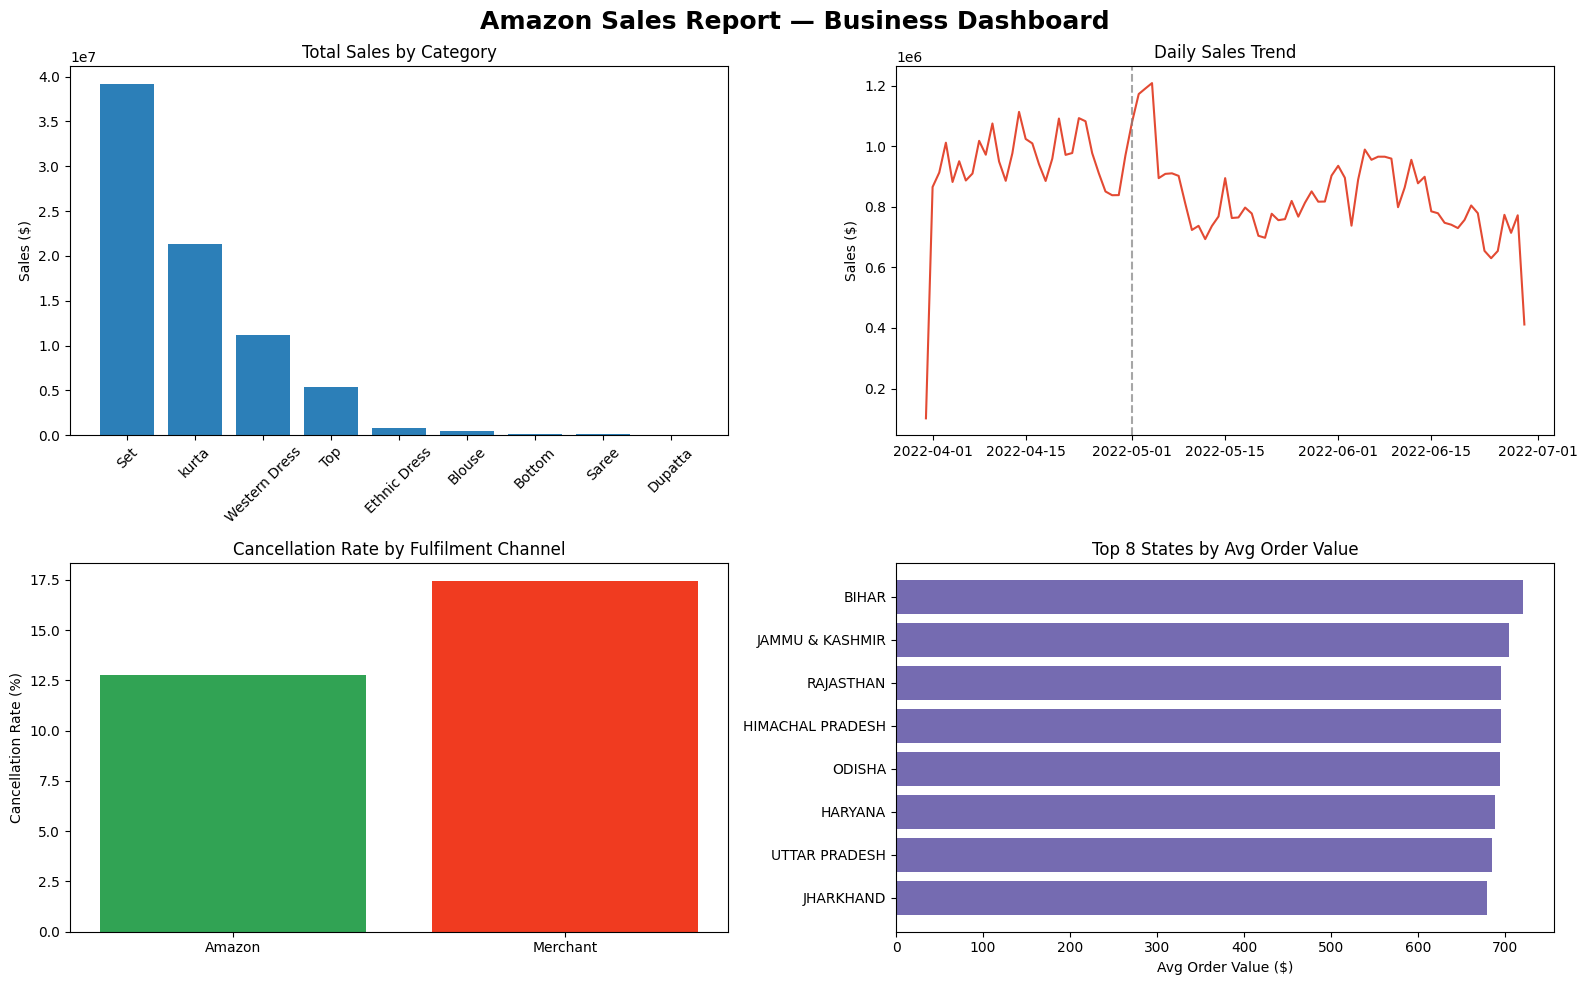

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Amazon Sales Report — Business Dashboard', fontsize=18, fontweight='bold')

# 1. Sales by category
sales_by_cat = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
axes[0,0].bar(sales_by_cat.index, sales_by_cat.values, color='#2c7fb8')
axes[0,0].set_title('Total Sales by Category')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylabel('Sales ($)')

# 2. Daily sales trend (with marker at the drop point)
sales_by_date = df.groupby('Date')['Amount'].sum()
axes[0,1].plot(sales_by_date.index, sales_by_date.values, color='#e34a33')
axes[0,1].set_title('Daily Sales Trend')
axes[0,1].set_ylabel('Sales ($)')
axes[0,1].axvline(pd.Timestamp('2022-05-01'), color='gray', linestyle='--', alpha=0.7)

# 3. Fulfilment comparison
fulfil = df.groupby('Fulfilment').agg(Cancellation_Rate=('Status', lambda x: (x=='Cancelled').mean()*100))
axes[1,0].bar(fulfil.index, fulfil['Cancellation_Rate'], color=['#31a354','#f03b20'])
axes[1,0].set_title('Cancellation Rate by Fulfilment Channel')
axes[1,0].set_ylabel('Cancellation Rate (%)')

# 4. Top 8 states by avg order value
state_summary = df.groupby('ship-state').agg(Total_Orders=('Order ID','count'), Avg_Order_Value=('Amount','mean'))
state_summary = state_summary[state_summary['Total_Orders']>=500].sort_values('Avg_Order_Value', ascending=False).head(8)
axes[1,1].barh(state_summary.index[::-1], state_summary['Avg_Order_Value'][::-1], color='#756bb1')
axes[1,1].set_title('Top 8 States by Avg Order Value')
axes[1,1].set_xlabel('Avg Order Value ($)')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()